In [28]:
from pathlib import Path

data_dir = Path("../data/bottle")

In [29]:
train_images = list((data_dir / "train" / "good").glob("*.png"))
print(len(train_images))
print(train_images[:5])

image_path = train_images[0]
print(image_path)
print(image_path.name)
print(image_path.parent)
print(image_path.parent.name)
print(image_path.parts)

train_records = []

for image_path in train_images:
    train_records.append({"path":image_path,
                        "split":"train",
                        "label":"normal",
                        "defect_type":"good"})

209
[WindowsPath('../data/bottle/train/good/000.png'), WindowsPath('../data/bottle/train/good/001.png'), WindowsPath('../data/bottle/train/good/002.png'), WindowsPath('../data/bottle/train/good/003.png'), WindowsPath('../data/bottle/train/good/004.png')]
..\data\bottle\train\good\000.png
000.png
..\data\bottle\train\good
good
('..', 'data', 'bottle', 'train', 'good', '000.png')


In [30]:
test_images = list((data_dir / "test").rglob("*.png"))
print(test_images[:5])

image_path = test_images[0]
print(image_path)
print(image_path.parts)

test_records = []

for image_path in test_images:
    defect_type = image_path.parent.name
    test_records.append({"path":image_path,
                        "split":"test",
                        "label":"normal" if defect_type == "good" else "defective",
                        "defect_type":defect_type})

[WindowsPath('../data/bottle/test/broken_large/000.png'), WindowsPath('../data/bottle/test/broken_large/001.png'), WindowsPath('../data/bottle/test/broken_large/002.png'), WindowsPath('../data/bottle/test/broken_large/003.png'), WindowsPath('../data/bottle/test/broken_large/004.png')]
..\data\bottle\test\broken_large\000.png
('..', 'data', 'bottle', 'test', 'broken_large', '000.png')


In [ ]:
import pandas as pd

record_df = pd.DataFrame(train_records + test_records)

print(f"Total number of images: {record_df.shape[0]}\n")

print(f"Number of images by split:\n{record_df.value_counts('split')}\n")

print(f"Number of images (train + test) by label:\n{record_df.value_counts('label')}\n")

print(
    f"Number of test images by label:\n"
    f"{record_df[record_df['split'] == 'test'].value_counts('label')}\n"
)

print(f"Defect types: {record_df['defect_type'].unique()}\n")

print(
    "Test images number by defect type:\n"
    f"{record_df[record_df['split'] == 'test']['defect_type'].value_counts()}\n"
)

print(f"Duplicates: {record_df['path'].duplicated().sum()}\n")

print(f"Missing values:\n {record_df.isna().sum()}")

Total number of images: 292

Number of images by split:
split
train    209
test      83
Name: count, dtype: int64

Number of images (train + test) by label:
label
normal       229
defective     63
Name: count, dtype: int64

Number of test images by label:
label
defective    63
normal       20
Name: count, dtype: int64

Defect types: <StringArray>
['good', 'broken_large', 'broken_small', 'contamination']
Length: 4, dtype: str

Test images number by defect_type
broken_small     22
contamination    21
broken_large     20
good             20
Name: count, dtype: int64

Duplicates: 0

Missing values:
 path           0
split          0
label          0
defect_type    0
dtype: int64


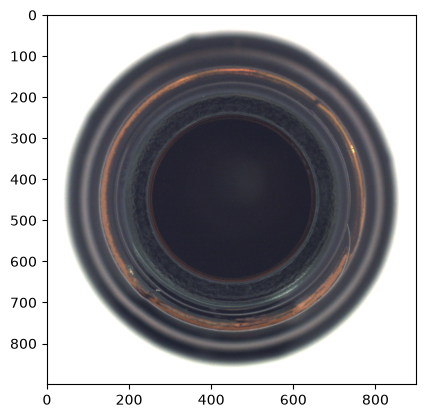

(900, 900)
RGB


In [68]:
import matplotlib.pyplot as plt
from PIL import Image

image_path = record_df.iloc[0]["path"]

image = Image.open(image_path)

plt.imshow(image)
plt.axis()
plt.show()

print(image.size)
print(image.mode)

In [69]:
image_sizes = []
image_modes = []

for image_path in record_df["path"]:
    image = Image.open(image_path)
    image_sizes.append(image.size)
    image_modes.append(image.mode)

print(set(image_sizes))
print(set(image_modes))

{(900, 900)}
{'RGB'}


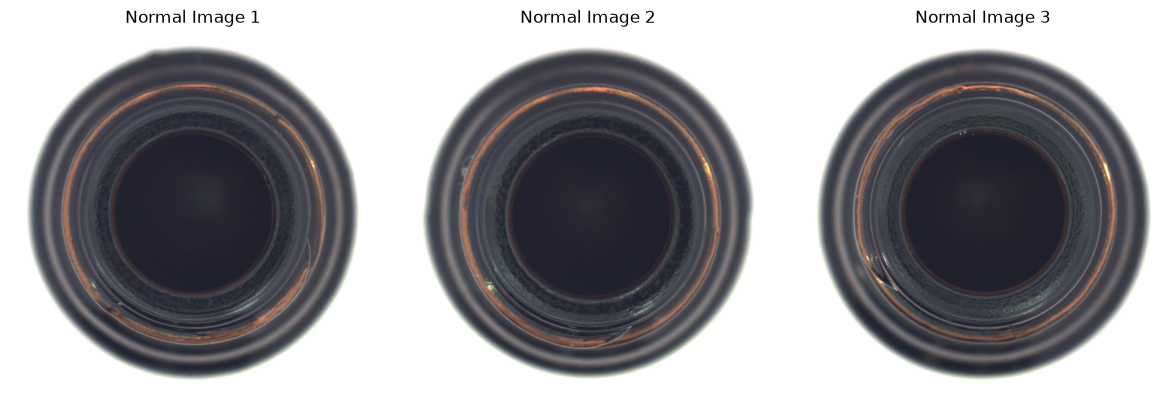

In [83]:
normal_df = record_df[record_df["label"] == "normal"]

fig, ax = plt.subplots(1, 3, figsize=(12, 4))

for i in range(3):
    img_path = normal_df["path"].iloc[i]
    img = Image.open(img_path)
    
    ax[i].imshow(img)
    ax[i].set_title(f"Normal Image {i+1}")
    ax[i].axis('off')

plt.tight_layout()


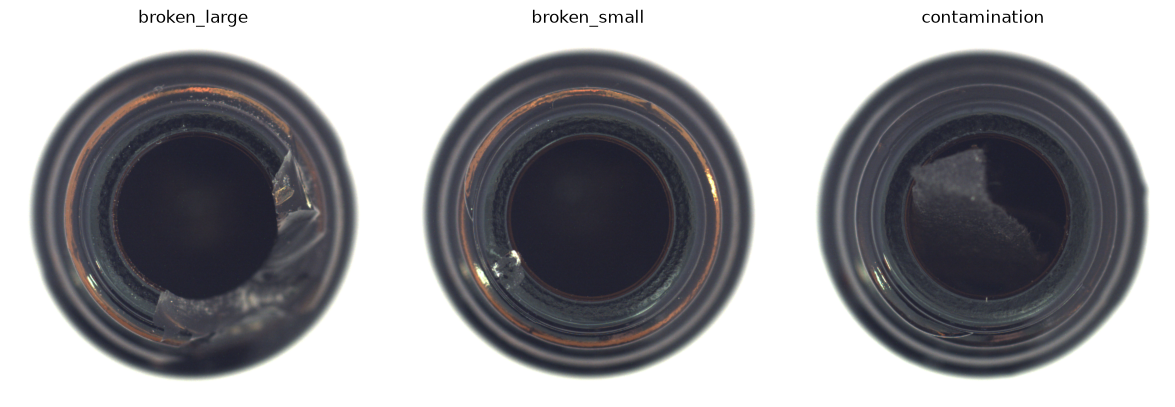

In [84]:
defective_df = record_df[record_df["label"] == "defective"]
defect_types = defective_df["defect_type"].unique()

fig, ax = plt.subplots(1, 3, figsize=(12, 4))

for i, defect_type in enumerate(defect_types):
    defect_df = defective_df[defective_df["defect_type"] == defect_type]
    img_path = defect_df["path"].iloc[0]
    img = Image.open(img_path)
    
    ax[i].imshow(img)
    ax[i].set_title(f"{defect_type}")
    ax[i].axis('off')

plt.tight_layout()